# 2.01 QComponent lifecycle — use, copy, delete, rename


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/tutorials/2%20From%20components%20to%20chip/A.%20Using%20QComponents/2.01%20How%20to%20use%20a%20QComponent.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=tutorials%2F2%20From%20components%20to%20chip%2FA.%20Using%20QComponents%2F2.01%20How%20to%20use%20a%20QComponent.ipynb)

> 💡 **Running in Colab or Binder?** Skip the desktop GUI install — the cell below grabs the lite (no-Qt) wheel, and `qm.gui(design)` auto-picks an inline matplotlib viewer with the same API (`gui.rebuild()`, `gui.screenshot()`, `gui.edit_component(...)`) as the desktop `MetalGUI`.

In [1]:
# In Colab / Binder, uncomment to install Quantum Metal (lite, no Qt).
# Locally you should already have it via `pip install quantum-metal` or
# `pip install 'quantum-metal[gui]'` for the desktop GUI.
# !pip install -q quantum-metal

> 💡 **Using this tutorial without the Qt GUI**
> 
> This tutorial uses the desktop `MetalGUI`. To follow along on Colab, Binder, JupyterHub, or any environment where Qt isn't available, **replace any `gui.rebuild()` / `gui.screenshot()` call with `qm.view(design)`** — it renders the design to a matplotlib `Figure` you can display inline or save with `fig.savefig(...)`.
> 
> See [1.1 Quick start](../1-Overview/1.1-Quick-start.ipynb) for a complete runnable walkthrough and [`docs/headless-usage.rst`](../../docs/headless-usage.rst) for the full reference.

Now, let's import Qiskit Metal:

In [2]:
import qiskit_metal as metal
import qiskit_metal as qm  # alias used by qm.gui / qm.view
from qiskit_metal import designs, draw
from qiskit_metal import Dict, open_docs

%metal_heading Welcome to Qiskit Metal!

Just as we did in the "Start Here" notebook, we'll open the Qiskit Metal GUI and work with simple planar designs:

In [3]:
design = designs.DesignPlanar()
gui = qm.gui(design)

Let's load a QComponent with all default options, corresponding to a transmon qubit. This particular QComponent is stored in the library qiskit_metal.qlibrary.qubits and we'll create a new object of the class TransmonPocket. 

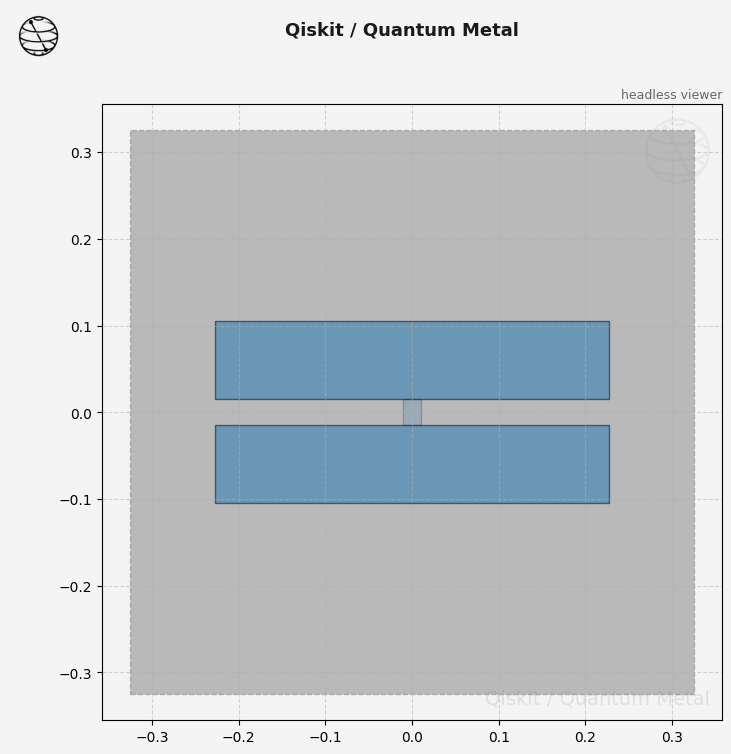

In [4]:
# Select a QComponent to create (The QComponent is a python class named `TransmonPocket`)
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

# Create a new qcomponent object
q1 = TransmonPocket(design)
gui.rebuild()  # rebuild the design and plot

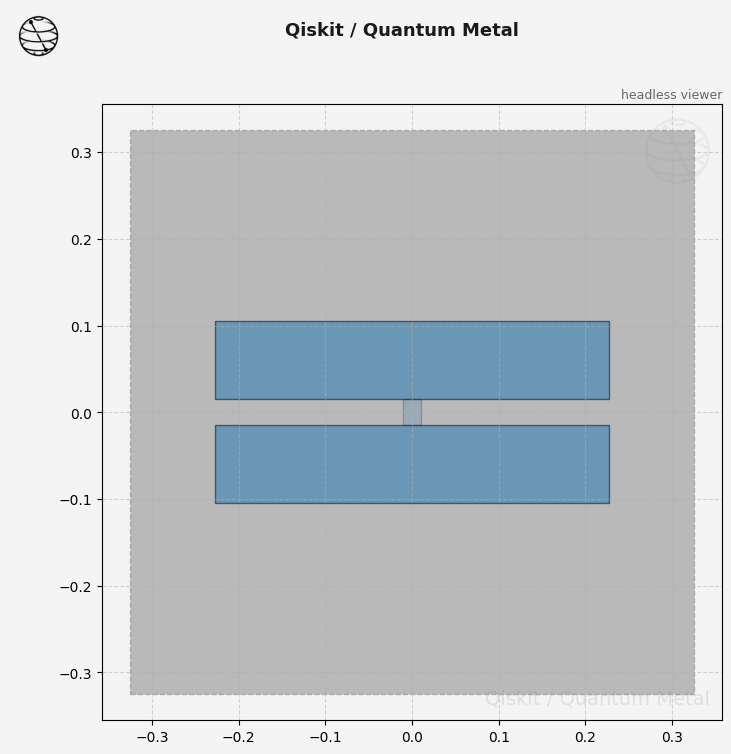

In [5]:
gui.screenshot()

We see that this QComponent consists of two large metallic pads with a thin strip of metal connecting them, corresponding to a Josephson Junction. The transmon qubit is centered at the origin by default. In the GUI, we can see that the ID assigned to our QComponent is "1" and that the QComponent class is "Transmon Pocket." 

Note that since we didn't give the QComponent an explicit name, one was assigned automatically ("Pocket_1") which we can also see in the GUI. Taking a look at the actual QComponent python script, we see that there is a "short name" defined in the QComponent metadata (short_name = "Pocket" in the dictionary), which is where this name comes from. 

It is easy to give a specific name to a QComponent object. We can delete the QComponent "Pocket_1" by just clicking the "Delete all" button in the Qiskit Metal GUI. Alternatively, this can done by executing the following command, which deletes all components in the design (more on deleting later in this tutorial): 

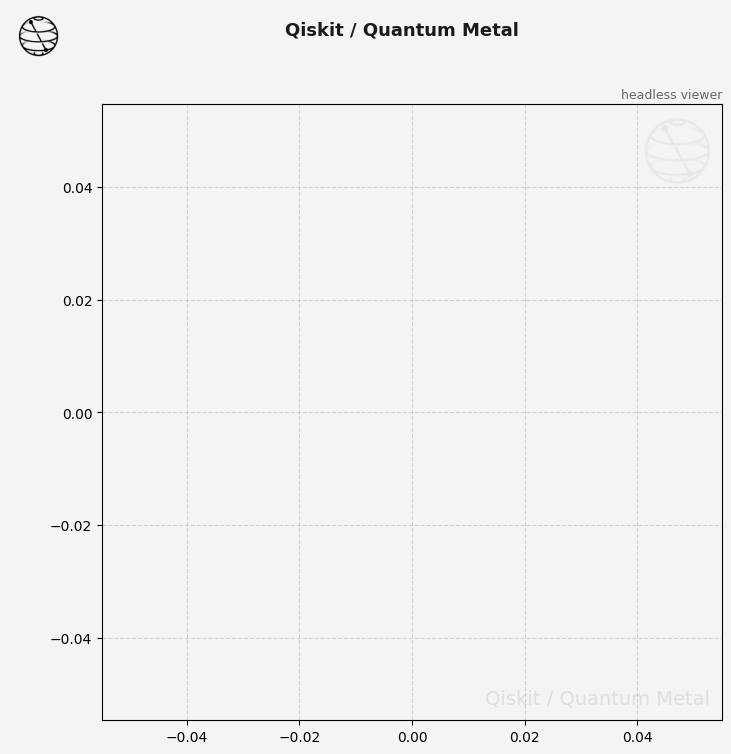

In [6]:
# Delete all QComponents in our design, which in this case is just the transmon pocket "Pocket_1"
design.delete_all_components()
gui.rebuild()  # rebuild the design and plot

Then, we can create the same transmon pocket with the name "Q1" by typing the command:

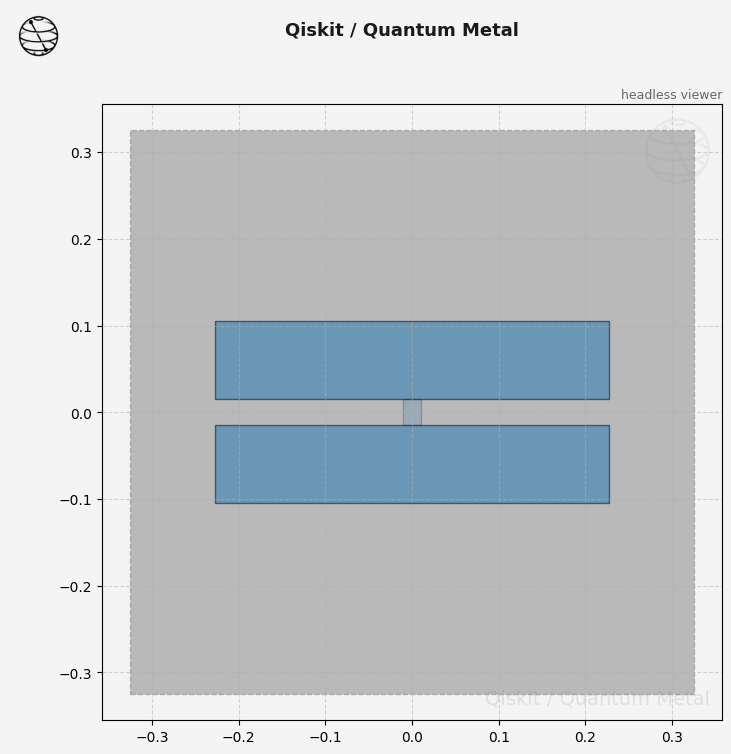

In [7]:
# Create a new qcomponent object with name 'Q1'
q1 = TransmonPocket(design, "Q1")
gui.rebuild()  # rebuild the design and plot

The QComponent we've just created as a name "Q1" and a QComponent ID of 2, since an ID of 1 was already used for the now-deleted "Pocket_1" object. It is worth noting that the QComponent we've just created is not functional yet; it's just two rectangular metal pads with a thin strip of metal connecting them. In order for a QComponent to be functional in an actual design, we will need to add a few additional things, such as QPins defining where the transmon pocket connects to coplanar waveguides (CPWs). We will discuss this in more detail later in the tutorial. 

## QComponent Default Options

QComponents come with some default options, which are used in the make function of the qcomponent to create the qgeometry that you see in the GUI. These options are parsed by Qiskit Metal, and can be changed using either the GUI or the script API. 

We can see what the options and other parameters are for our QComponent by typing the following command:

In [8]:
q1

name:    Q1
class:   TransmonPocket        
options: 
  'pos_x'             : '0.0um',                      
  'pos_y'             : '0.0um',                      
  'orientation'       : '0.0',                        
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'connection_pads'   : {
                        },
  'pad_gap'           : '30um',                       
  'inductor_width'    : '20um',                       
  'pad_width'         : '455um',                      
  'pad_height'        : '90um',                       
  'pocket_width'      : '650um',                      
  'pocket_height'     : '650um',                      
  'hfss_wire_bonds'   : False,                        
  'q3d_wire_bonds'    : False,                        
  'aedt_q3d_wire_bonds': False,                        
  'aedt_hfss_wire_bonds': False,                        
  'hfss_inductance'   : '10nH',                       
  'hfss_ca

We can see the full list of template options for the class by typing this command:

In [9]:
TransmonPocket.get_template_options(design)

{'pos_x': '0.0um',
 'pos_y': '0.0um',
 'orientation': '0.0',
 'chip': 'main',
 'layer': '1',
 'connection_pads': {},
 '_default_connection_pads': {'pad_gap': '15um',
  'pad_width': '125um',
  'pad_height': '30um',
  'pad_cpw_shift': '5um',
  'pad_cpw_extent': '25um',
  'cpw_width': 'cpw_width',
  'cpw_gap': 'cpw_gap',
  'cpw_extend': '100um',
  'pocket_extent': '5um',
  'pocket_rise': '65um',
  'loc_W': '+1',
  'loc_H': '+1'},
 'pad_gap': '30um',
 'inductor_width': '20um',
 'pad_width': '455um',
 'pad_height': '90um',
 'pocket_width': '650um',
 'pocket_height': '650um',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False,
 'hfss_inductance': '10nH',
 'hfss_capacitance': 0,
 'hfss_resistance': 0,
 'hfss_mesh_kw_jj': 7e-06,
 'q3d_inductance': '10nH',
 'q3d_capacitance': 0,
 'q3d_resistance': 0,
 'q3d_mesh_kw_jj': 7e-06,
 'gds_cell_name': 'my_other_junction',
 'aedt_q3d_inductance': 1e-08,
 'aedt_q3d_capacitance': 0,
 'aedt_hf

## Modifying the Options

We can modify the QComponent by changing the default options. This can be done using either the python API or the GUI. Here's an example where we'll move the transmon from (0,0) to (2,2), while also modifying the pad height and width:

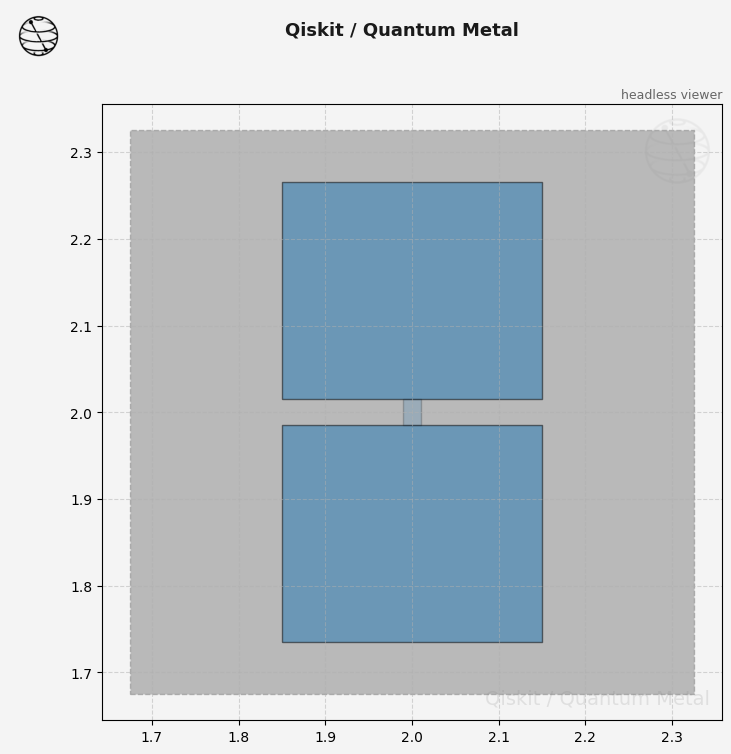

In [10]:
# Change options
q1.options.pos_x = "2.0 mm"
q1.options.pos_y = "2.0 mm"
q1.options.pad_height = "250 um"
q1.options.pad_width = "300 um"

# Update the geometry and render to the gui, since we changed the options
gui.rebuild()

## Copying a QComponent

We can copy a QComponent using the "design.copy_qcomponent" command. Let's make a copy of our transmon qubit, which is located at (2,2) and place the copy at (-2,2):

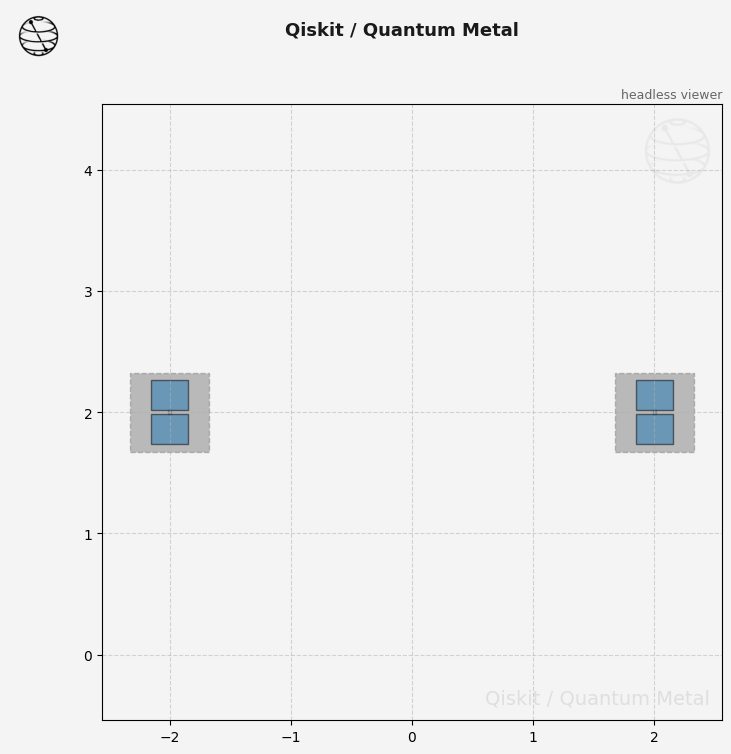

In [11]:
# Copy q1 and place the new Qcomponent ("q1_copy") at (-2,2):
q1_copy = design.copy_qcomponent(q1, "Q1_copy")
q1_copy.options["pos_x"] = "-2.0mm"
gui.rebuild()
gui.autoscale()

We can also copy multiple QComponents at the same time. For example, let's suppose we want to take our two transmon qubits at (-2,2) and (2,2) and create copies which are located at (-2,2) and (-2,2):

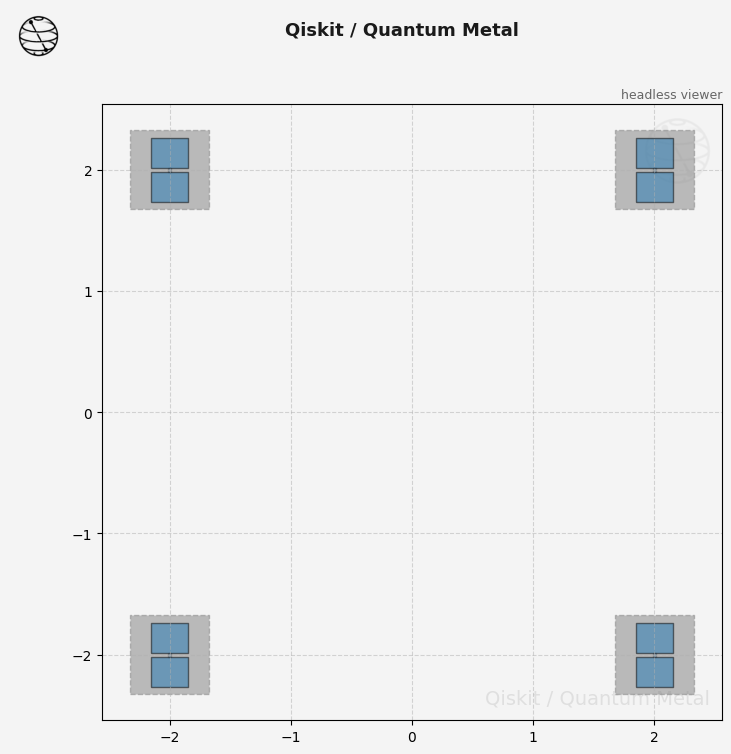

In [12]:
# Let's copy the two QComponents and change the y-coordinates of the copies to both be -2:
newcopies = design.copy_multiple_qcomponents(
    [q1, q1_copy], ["Q3", "Q4"], [dict(pos_y="-2.0mm"), dict(pos_y="-2.0mm")]
)
gui.rebuild()
gui.autoscale()

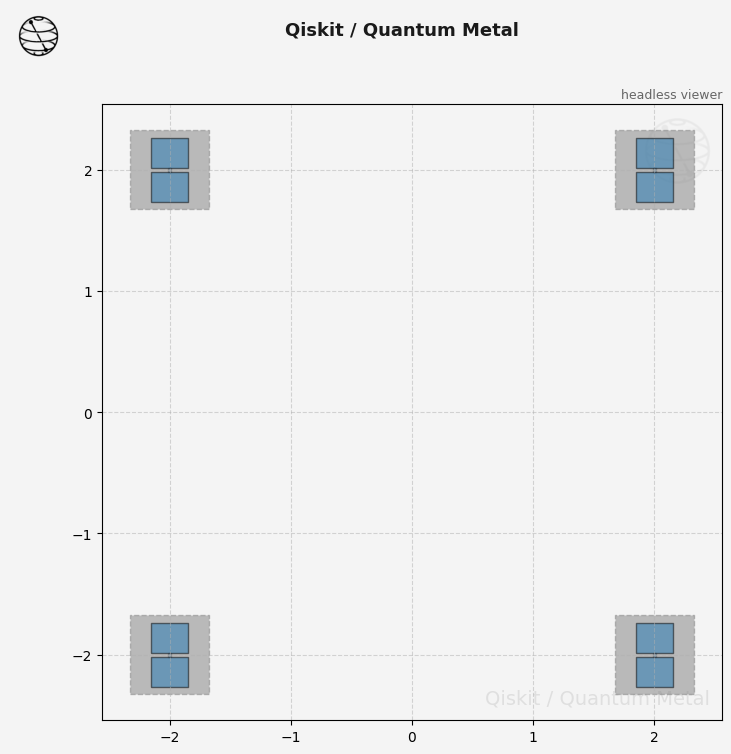

In [13]:
gui.screenshot()

Now we have four transmon qubits located at the corners of a square: (-2,-2), (-2,2), (2,2) and (2,-2). 

### More copy patterns

The cells below — adapted from the standalone *How to copy a QComponent* tutorial — explore richer copy scenarios: bulk copies via lists, partial option overrides, default-overwrite semantics.

Now we'll put one transmon at the origin:

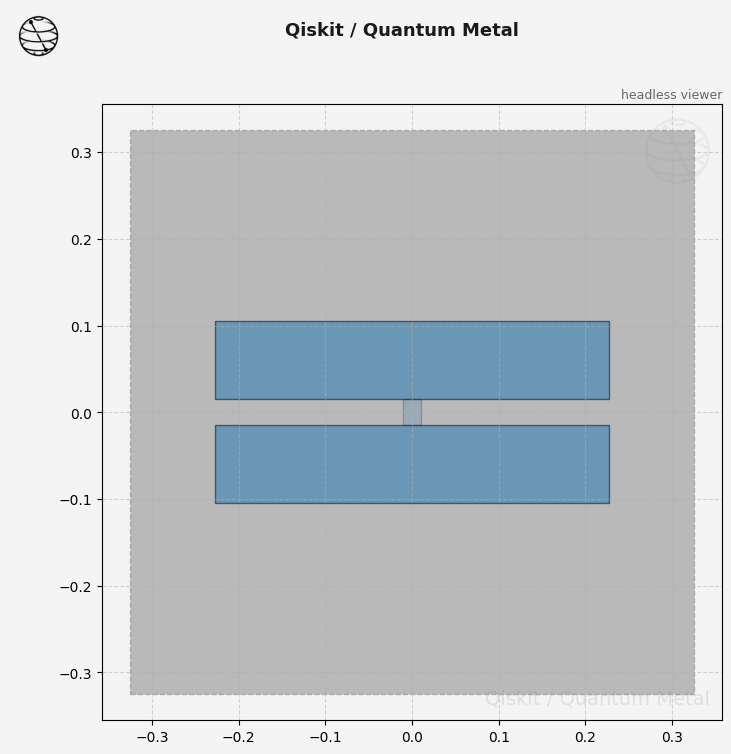

In [14]:
# Let's start by putting a transmon at the origin:
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

design.overwrite_enabled = True
# Clear any prior copies from earlier in the notebook so the
# copy_qcomponent() calls below can reuse the "Q1_copy"/"Q3"/"Q4" names.
for _name in ("Q1_copy", "Q1_another_copy", "Q3", "Q4", "Q5", "Q6", "Q7", "Q8"):
    if _name in design.components:
        design.delete_component(_name)
q1 = TransmonPocket(design, "Q1")
gui.rebuild()
gui.autoscale()

First, we'll copy the component and then manually modify the coordinates to be at (1,0) instead of (0,0):

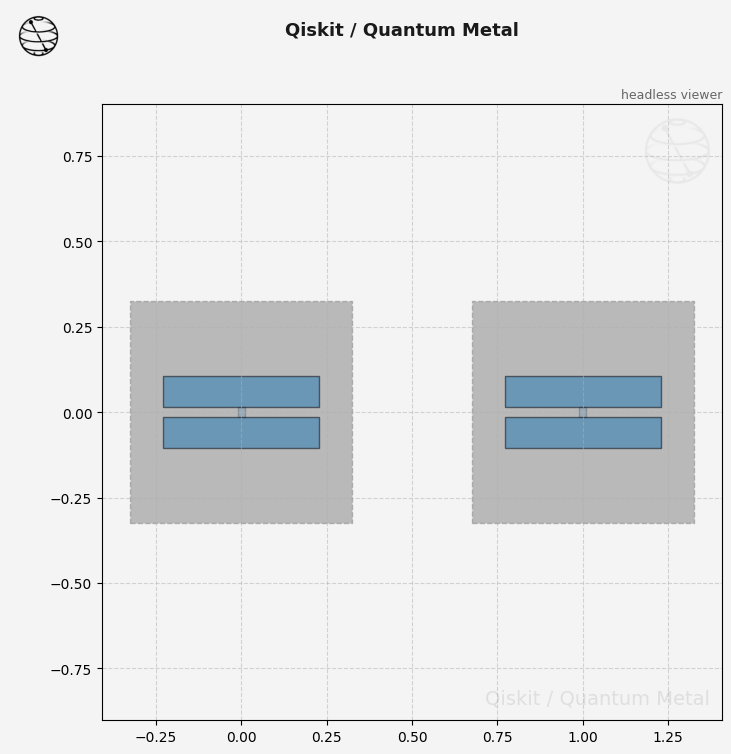

In [15]:
# Now let's copy the transmon at the origin and put it at position (0,1):
q1_copy = design.copy_qcomponent(q1, "Q1_copy")
q1_copy.options["pos_x"] = "1.0mm"
gui.rebuild()
gui.autoscale()

Now, we'll copy the original component and in the same step we'll move the copy to (-1,0) by passing a dictionary to the "copy_qcomponent" command:

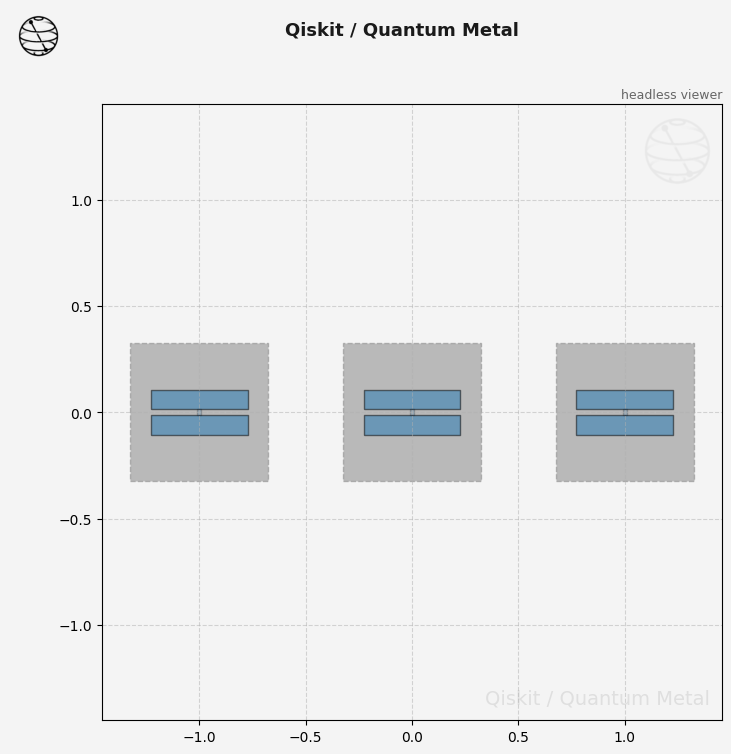

In [16]:
# Now let's copy the transmon at the origin and put it at position (0,-1):
q1_anothercopy = design.copy_qcomponent(q1, "Q1_another_copy", dict(pos_x="-1.0mm"))
gui.rebuild()
gui.autoscale()

We can copy multiple components at once using the "copy_multiple_qcomponents" command. Here's an example that copies the three components we've just created (Q1 and the two copies: Q1_copy and Q1_another_copy) and moves them up by 2.0mm each: 

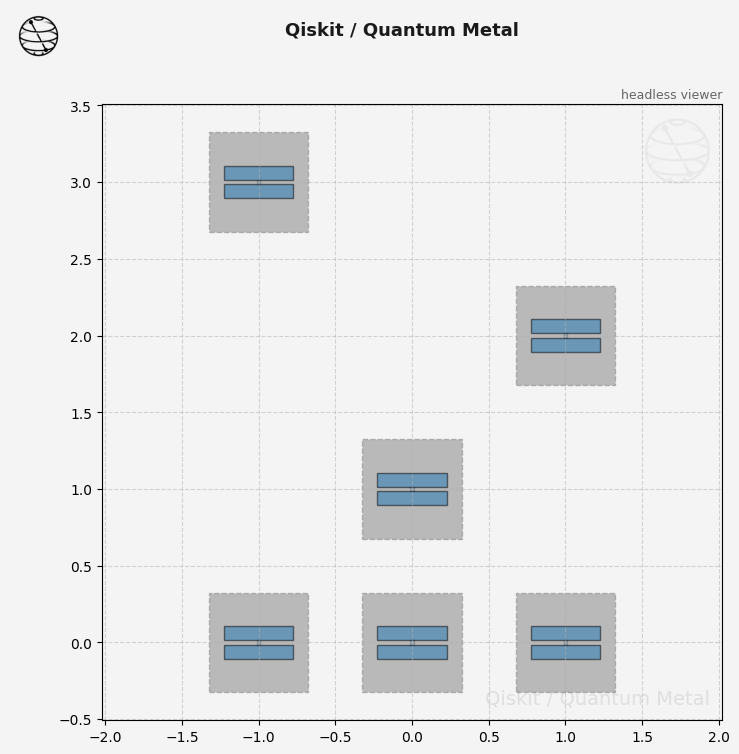

In [17]:
# Now let's copy all three components at the same time, moving them up by +2mm in the y-direction:
newcopies = design.copy_multiple_qcomponents(
    [q1, q1_copy, q1_anothercopy],
    ["Q3", "Q4", "Q5"],
    [dict(pos_y="1.0mm"), dict(pos_y="2.0mm"), dict(pos_y="3.0mm")],
)
gui.rebuild()
gui.autoscale()

Note that we can also copy multiple QComponents without passing dictionaries. In this case, the copied QComponents will sit on top of of the original QComponents in the layout:

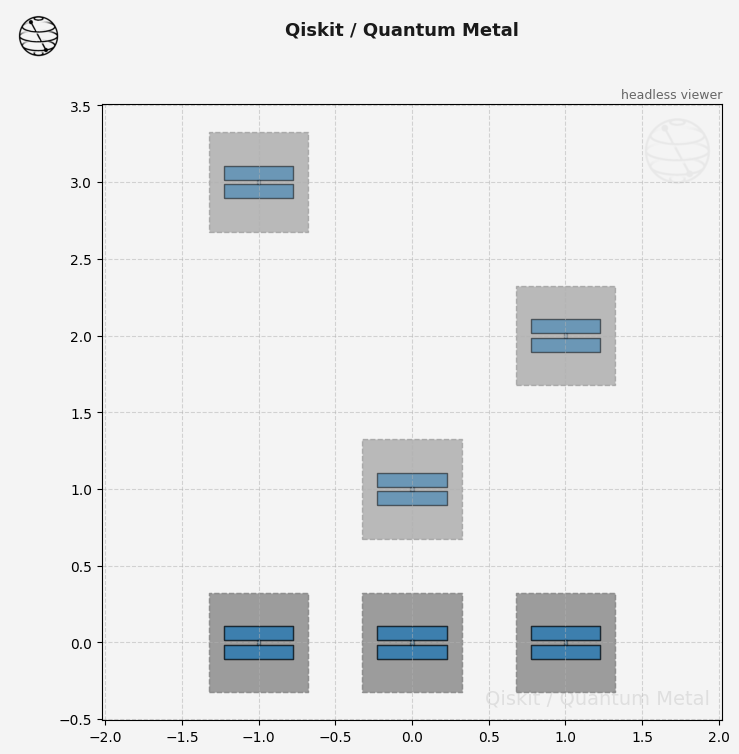

In [18]:
# Example of copying without giving any dictionary values; qcomponents will sit on top of the originals!
newcopies2 = design.copy_multiple_qcomponents(
    [q1, q1_copy, q1_anothercopy], ["Q6", "Q7", "Q8"]
)
gui.rebuild()
gui.autoscale()

Note also that we can copy multiple QComponents but only give a dictionary to one of them. The other two dictionaries still need to exist but can be empty: 

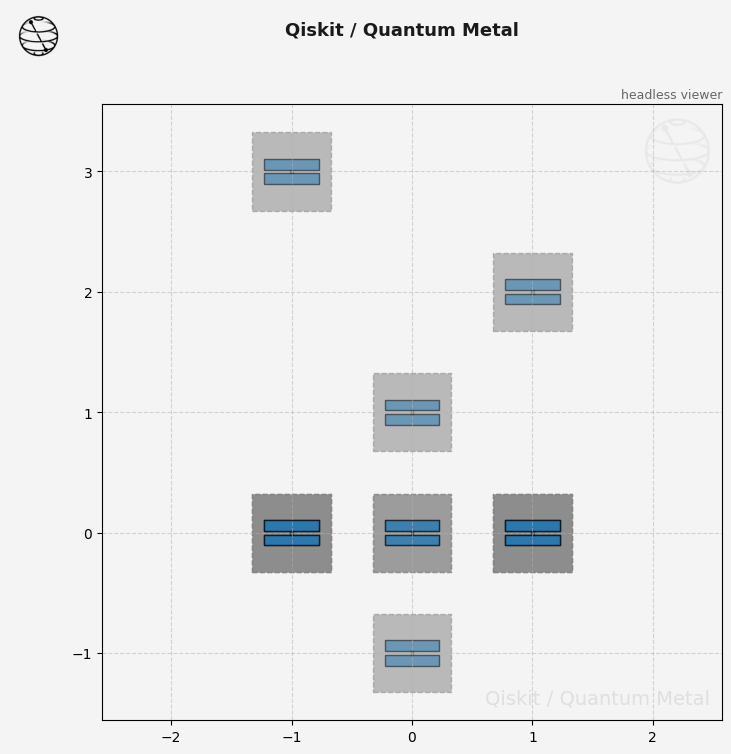

In [19]:
# Copy the three original components but only give a dictionary for the first one; other two dictionaries still need to exist but can be empty:
newcopies3 = design.copy_multiple_qcomponents(
    [q1, q1_copy, q1_anothercopy],
    ["Q9", "Q10", "Q11"],
    [dict(pos_y="-1.0mm"), dict(), dict()],
)
gui.rebuild()
gui.autoscale()

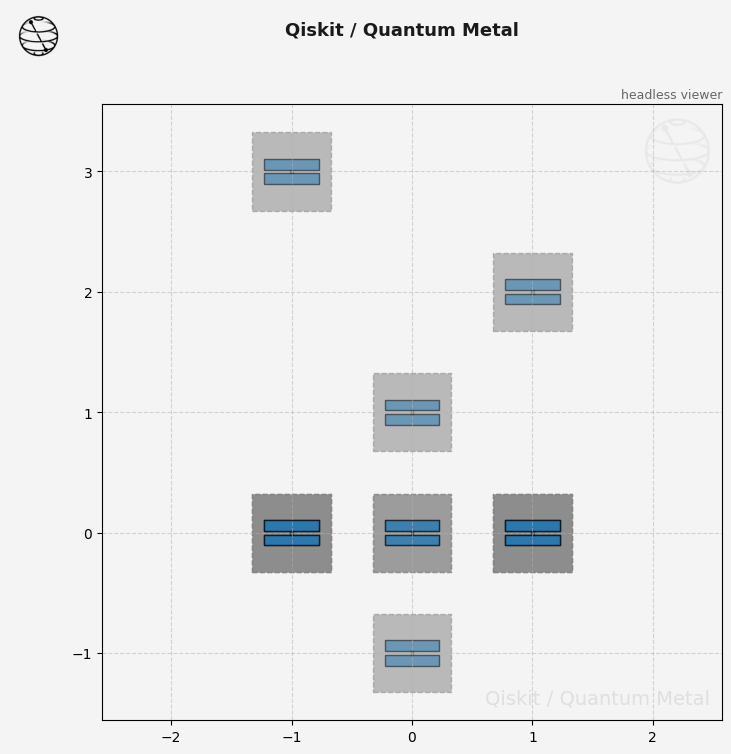

In [20]:
gui.screenshot()

## Deleting a QComponent

We saw in an earlier example how to delete all QComponents in a design using either the "design.delete_all_components" command or by using the "Delete all" button in the GUI. But what if we only want to delete specific QComponents without deleting everything in a design? 

We can delete a specific QComponent using either the GUI or the python API. If you wish to remove a specific QComponent, you can do so using the "delete_component" or "_delete_component" commands. The first takes the string reference to a Qcomponent, while the second takes an integer reference to a QComponent. Suppose we want to remove qubit 'Q1'. Presently, we do not need to pass a Boolean corresponding to whether we want to force the delete (true=1) even if the component has dependencies, or whether the deletion should not be executed in the event the QComponent does have dependencies (false=0). The bool option is for future potential possibilities of having QComponents with dependencies. 

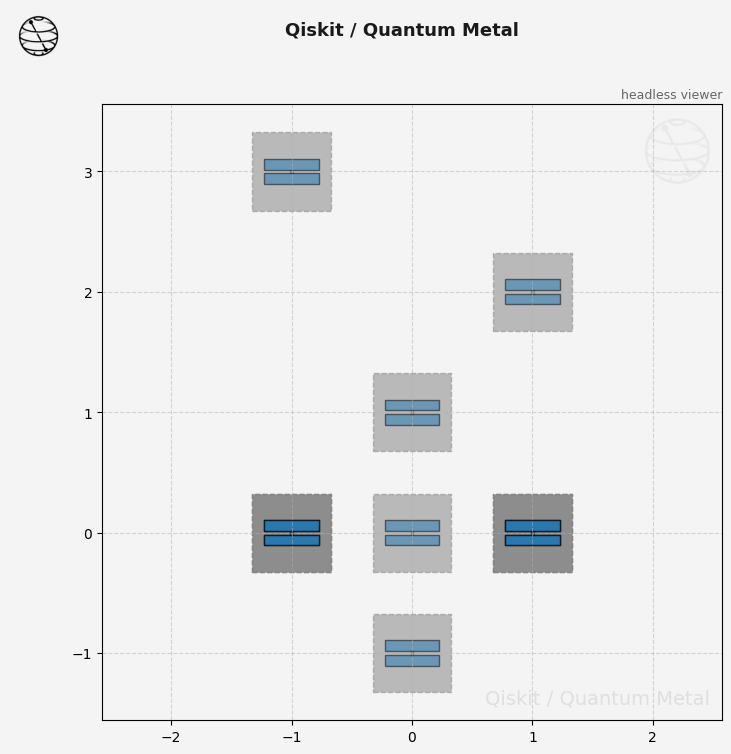

In [21]:
design.delete_component("Q1")
gui.rebuild()
gui.autoscale()

We can also delete without checking for QComponent dependencies at all. In this case, we pass only the QComponent ID. As an example, we can force delete 'Q1_copy" which has QComponent ID=3 by typing:

07:22PM 34s WARNING [_delete_component]: Called _delete_complete, component_id: 3, but component_id is not in design.components dictionary.


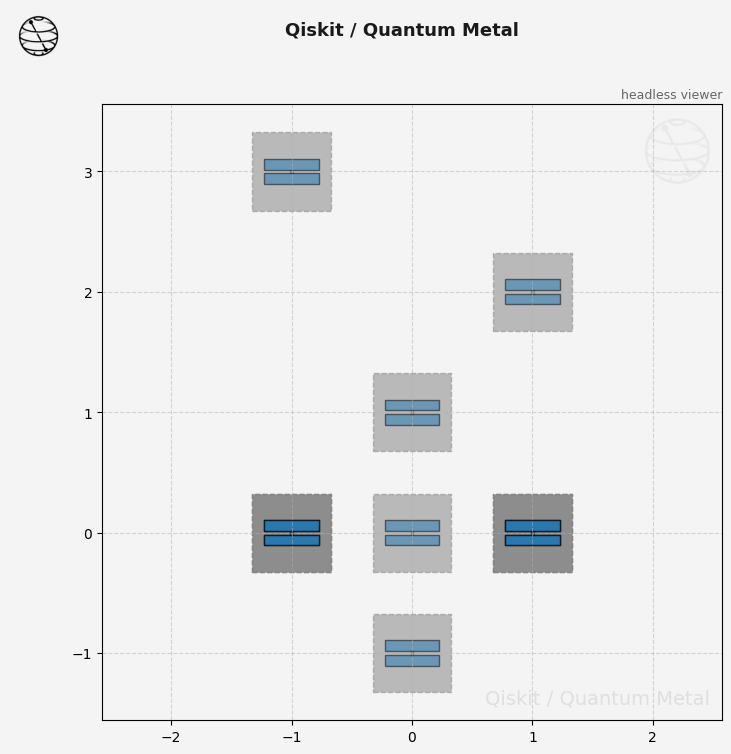

In [22]:
design._delete_component(3)
gui.rebuild()
gui.autoscale()

## Renaming a QComponent

In the first example in this notebook, we created a QComponent named "Pocket_1" then deleted it and created one with the name "Q1". One can also simply rename a QComponent without deleting it and creating a new one. We can rename a QComponent by using the "design_rename.component" command. For example, let's rename "Q3" and "Q4" to "Q_three" and "Q_four", respectively. Note that "Q3" has a QComponent ID of 4, while "Q4" has a QComponent ID of 5. 

In [23]:
design.rename_component(4, "Q_three")  # rename "Q3" to "Q_three"
design.rename_component(5, "Q_four")  # rename "Q4" to "Q_four"

07:22PM 34s WARNING [rename_component]: Called rename_component, component_id=4, but component_id is not in design.components dictionary.


07:22PM 34s WARNING [rename_component]: Called rename_component, component_id=5, but component_id is not in design.components dictionary.


-3

## Overwriting a QComponent

In order to enable component overwrite of QComponents with the same name, we can use the following command:

In [24]:
design.overwrite_enabled = True

This allows for the QComponent to be modified and re-built without having to delete it. Without this line, a QComponent would have to be deleted before recreating it with different options. 

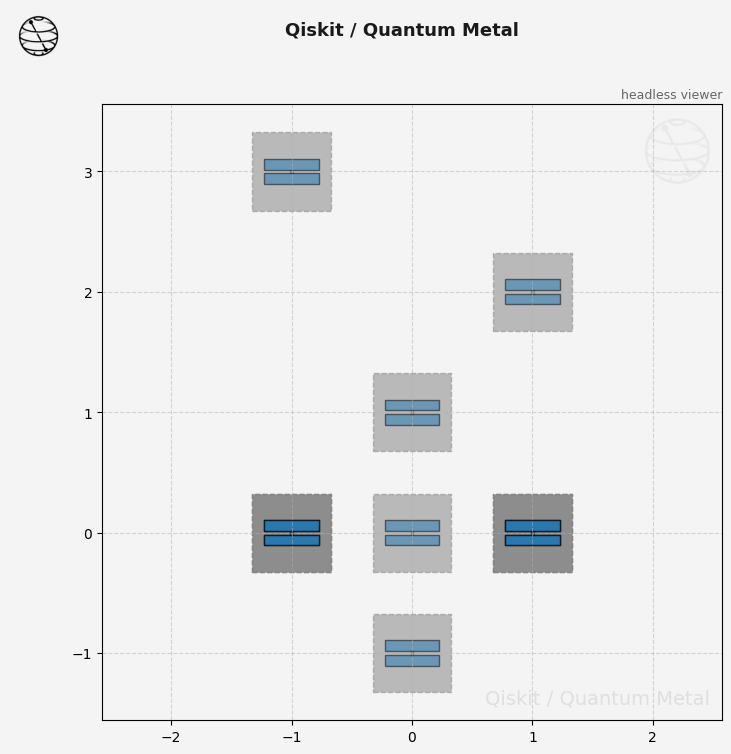

In [25]:
gui.screenshot()

## Closing the Qiskit Metal GUI

In [26]:
gui.main_window.close()